In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option('display.max_columns', None)



In [19]:
trades = pd.read_csv(r"C:\Users\udith\Downloads\historical_data (1).csv")
sentiment = pd.read_csv(r"C:\Users\udith\Downloads\fear_greed_index (1).csv")

print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

trades.head()


Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [20]:
print("Trades Columns:\n", trades.columns)
print("\nSentiment Columns:\n", sentiment.columns)

print("\nTrades Info:")
print(trades.info())

print("\nSentiment Info:")
print(sentiment.info())


Trades Columns:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment Columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trades Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         2

In [22]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)


In [23]:
# Create daily date column
trades['Date'] = trades['Timestamp IST'].dt.date
trades['Date'] = pd.to_datetime(trades['Date'])

# Fix sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date']

print("Date conversion successful")


Date conversion successful


In [25]:
# 1️⃣ Daily PnL per account
daily_pnl = trades.groupby(['Account', 'Date'])['Closed PnL'].sum().reset_index()

# 2️⃣ Win flag
trades['win'] = np.where(trades['Closed PnL'] > 0, 1, 0)

# 3️⃣ Daily win rate
daily_winrate = trades.groupby(['Account', 'Date'])['win'].mean().reset_index()
daily_winrate.rename(columns={'win': 'win_rate'}, inplace=True)

# 4️⃣ Trades per day
daily_trades = trades.groupby(['Account', 'Date']).size().reset_index(name='trade_count')

# 5️⃣ Average trade size (USD)
daily_size = trades.groupby(['Account', 'Date'])['Size USD'].mean().reset_index()
daily_size.rename(columns={'Size USD': 'avg_trade_size'}, inplace=True)

# 6️⃣ Long/Short ratio
long_short = trades.groupby(['Account', 'Date', 'Side']).size().unstack(fill_value=0)

# Handle case sensitivity
if 'BUY' in long_short.columns:
    long_short['long_short_ratio'] = long_short.get('BUY',0) / (long_short.get('SELL',1))
elif 'Long' in long_short.columns:
    long_short['long_short_ratio'] = long_short.get('Long',0) / (long_short.get('Short',1))
else:
    long_short['long_short_ratio'] = 0

long_short = long_short.reset_index()[['Account','Date','long_short_ratio']]

# 7️⃣ Merge everything
metrics = daily_pnl.merge(daily_winrate, on=['Account','Date'])
metrics = metrics.merge(daily_trades, on=['Account','Date'])
metrics = metrics.merge(daily_size, on=['Account','Date'])
metrics = metrics.merge(long_short, on=['Account','Date'])

metrics.head()


,Account,Date,Closed PnL,win_rate,trade_count,avg_trade_size,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,177,5089.718249,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,68,7976.664412,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,40,23734.500000,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,12,28186.666667,inf
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,27,17248.148148,0.8


In [26]:
final_df = metrics.merge(
    sentiment[['Date','classification']],
    on='Date',
    how='inner'
)

print("Final dataset shape:", final_df.shape)
final_df.head()


Final dataset shape: (2340, 8)


,Account,Date,Closed PnL,win_rate,trade_count,avg_trade_size,long_short_ratio,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,177,5089.718249,0.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,68,7976.664412,0.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,40,23734.500000,0.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,12,28186.666667,inf,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,27,17248.148148,0.8,Extreme Greed


In [27]:
performance_summary = final_df.groupby('classification').agg({
    'Closed PnL': 'mean',
    'win_rate': 'mean',
    'trade_count': 'mean',
    'avg_trade_size': 'mean',
    'long_short_ratio': 'mean'
}).reset_index()

performance_summary


,classification,Closed PnL,win_rate,trade_count,avg_trade_size,long_short_ratio
0,Extreme Fear,4619.439053,0.329659,133.750000,6773.464125,inf
1,Extreme Greed,5161.922644,0.386387,76.030418,5371.637182,inf
2,Fear,5328.818161,0.364033,98.153968,8975.928546,inf
3,Greed,3318.100730,0.343559,77.628086,6427.866594,inf
4,Neutral,3438.618818,0.355414,100.228723,6963.694861,inf


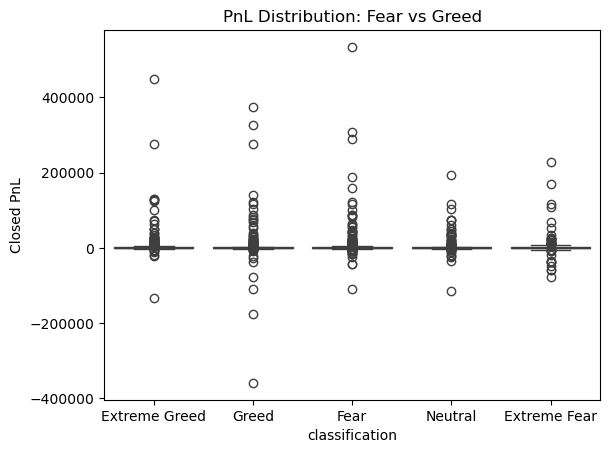

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=final_df, x='classification', y='Closed PnL')
plt.title("PnL Distribution: Fear vs Greed")
plt.show()


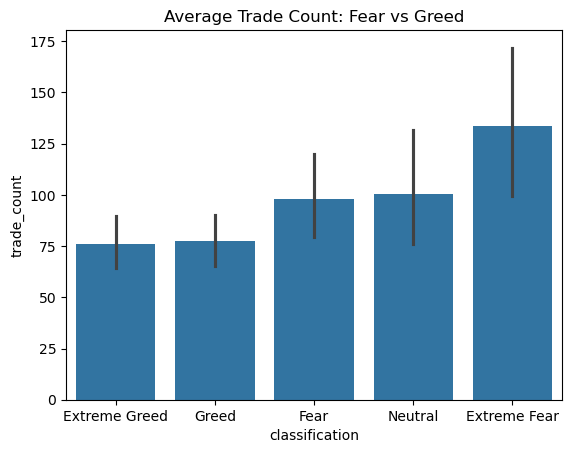

In [29]:
sns.barplot(data=final_df, x='classification', y='trade_count')
plt.title("Average Trade Count: Fear vs Greed")
plt.show()


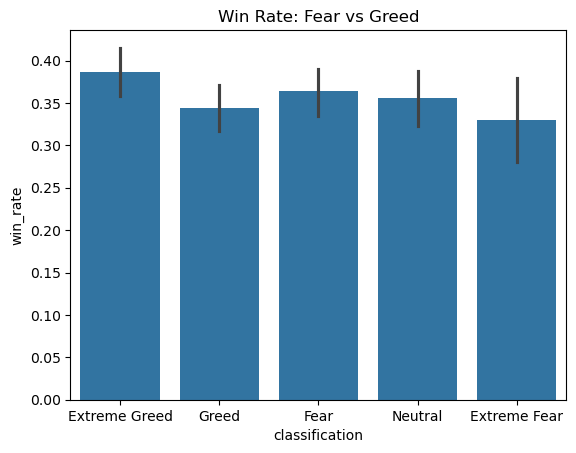

In [30]:
sns.barplot(data=final_df, x='classification', y='win_rate')
plt.title("Win Rate: Fear vs Greed")
plt.show()


In [31]:
#High vs Low Activity Traders

#High vs Low PnL Traders

#Consistent vs Inconsistent Traders

In [32]:
# Calculate average trade frequency per account
account_activity = final_df.groupby('Account')['trade_count'].mean().reset_index()

median_activity = account_activity['trade_count'].median()

account_activity['activity_segment'] = np.where(
    account_activity['trade_count'] > median_activity,
    'High Activity',
    'Low Activity'
)

# Merge back
final_df = final_df.merge(
    account_activity[['Account','activity_segment']],
    on='Account'
)

# Compare performance
activity_perf = final_df.groupby(['classification','activity_segment'])['Closed PnL'].mean().reset_index()

activity_perf


,classification,activity_segment,Closed PnL
0,Extreme Fear,High Activity,5406.205623
1,Extreme Fear,Low Activity,3727.770274
2,Extreme Greed,High Activity,4340.279167
3,Extreme Greed,Low Activity,5800.361832
4,Fear,High Activity,8672.944447
5,Fear,Low Activity,2249.775057
6,Greed,High Activity,5494.049560
7,Greed,Low Activity,1942.374895
8,Neutral,High Activity,4130.277361
9,Neutral,Low Activity,2891.879207


In [33]:
# Standard deviation of daily PnL (volatility proxy)
account_volatility = final_df.groupby('Account')['Closed PnL'].std().reset_index()

median_vol = account_volatility['Closed PnL'].median()

account_volatility['consistency_segment'] = np.where(
    account_volatility['Closed PnL'] < median_vol,
    'Consistent',
    'Inconsistent'
)

final_df = final_df.merge(
    account_volatility[['Account','consistency_segment']],
    on='Account'
)

consistency_perf = final_df.groupby(['classification','consistency_segment'])['Closed PnL'].mean().reset_index()

consistency_perf


,classification,consistency_segment,Closed PnL
0,Extreme Fear,Consistent,171.450889
1,Extreme Fear,Inconsistent,8643.809296
2,Extreme Greed,Consistent,2520.649196
3,Extreme Greed,Inconsistent,11971.736499
4,Fear,Consistent,287.474060
5,Fear,Inconsistent,10804.185265
6,Greed,Consistent,1199.721059
7,Greed,Inconsistent,6757.251531
8,Neutral,Consistent,554.109946
9,Neutral,Inconsistent,7418.510806


In [34]:
account_total_pnl = final_df.groupby('Account')['Closed PnL'].sum().reset_index()

account_total_pnl['profit_segment'] = np.where(
    account_total_pnl['Closed PnL'] > 0,
    'Profitable',
    'Struggling'
)

final_df = final_df.merge(
    account_total_pnl[['Account','profit_segment']],
    on='Account'
)

profit_perf = final_df.groupby(['classification','profit_segment'])['Closed PnL'].mean().reset_index()

profit_perf


,classification,profit_segment,Closed PnL
0,Extreme Fear,Profitable,5251.080111
1,Extreme Fear,Struggling,-1967.674838
2,Extreme Greed,Profitable,5338.976051
3,Extreme Greed,Struggling,682.471435
4,Fear,Profitable,5495.169303
5,Fear,Struggling,3479.761239
6,Greed,Profitable,4243.154168
7,Greed,Struggling,-14489.177956
8,Neutral,Profitable,3647.197298
9,Neutral,Struggling,942.869417


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Create profitability label
final_df['profitable_day'] = np.where(final_df['Closed PnL'] > 0, 1, 0)

features = final_df[['trade_count','win_rate','avg_trade_size']]
target = final_df['profitable_day']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))


Model Accuracy: 0.9487179487179487
